# Prescriptive Analysis

### 1. How can multi-source wearable and CGM data be used to build a patient-level prescriptive risk scoring system for Type 1 Diabetes that identifies high-risk individuals and recommends personalized intervention strategies?
###  Markers Chosen
Glucose,Heart rate,steps,carbs intake,Sleep quality,bolus_volume_delivered,basal_rate
### Why These Markers Were Chosen
These markers were chosen because Type 1 Diabetes management is influenced by multiple interacting factors, not just glucose levels alone. Heart rate reflects physiological stress, while activity and sleep capture lifestyle impacts on insulin sensitivity and glucose stability. Insulin and carbohydrate intake explain treatment and dietary effects on glucose changes. Together, they provide a holistic view of patient health and enable more accurate risk assessment.




TOP HIGH-RISK PATIENTS

   Patient_ID  risk_score  risk_score_normalized risk_category
12  HUPA0016P   79.541762             100.000000     High Risk
13  HUPA0017P   79.295903              99.438609     High Risk
3   HUPA0004P   77.349692              94.994650     High Risk
16  HUPA0020P   77.108792              94.444582     High Risk
10  HUPA0014P   76.616131              93.319645     High Risk
5   HUPA0006P   73.586766              86.402424     High Risk
20  HUPA0024P   71.790168              82.300091     High Risk
14  HUPA0018P   71.784335              82.286773     High Risk
22  HUPA0026P   70.239018              78.758211     High Risk
0   HUPA0001P   70.026398              78.272718     High Risk

RISK CATEGORY DISTRIBUTION

risk_category
High Risk        11
Moderate Risk     8
Low Risk          6
Name: count, dtype: int64


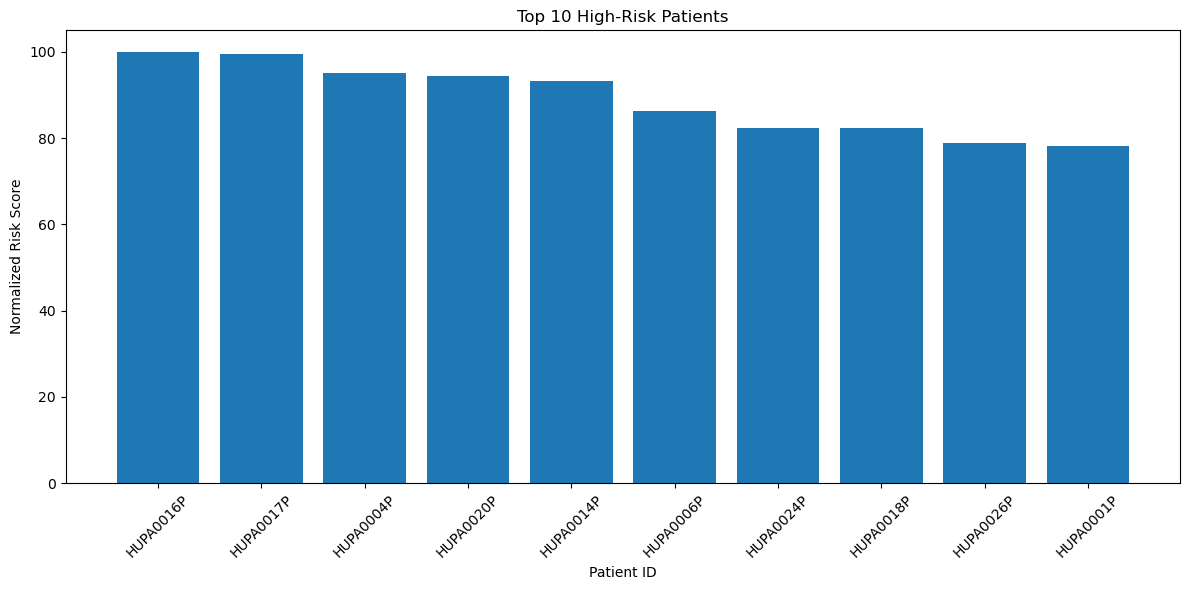

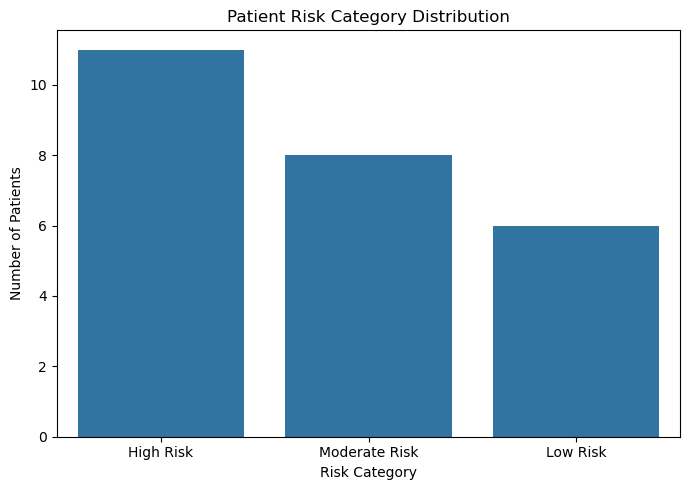

In [19]:
# =========================================================
# PATIENT-LEVEL PRESCRIPTIVE ANALYSIS FOR T1DM DATASET
# =========================================================

from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# 3. Create Clinical & Lifestyle Risk Markers
# ---------------------------------------------------------

# Hypoglycemia
df['hypo_event'] = (
    df['glucose'] < 70
).astype(int)

# Hyperglycemia
df['hyper_event'] = (
    df['glucose'] > 180
).astype(int)

# Heart-rate stress
df['hr_stress'] = (
    df['heart_rate'] > 100
).astype(int)

# Poor sleep indicator
df['sleep_poor'] = (

    (df['Average Sleep Duration (hrs)'] < 6) |

    (df['Sleep Quality (1-10)'] < 5)

).astype(int)

# Low activity
df['low_activity'] = (
    df['steps'] < 3000
).astype(int)

# ---------------------------------------------------------
# 4. Patient-Level Aggregation
# ---------------------------------------------------------

patient_summary = df.groupby('Patient_ID').agg({

    # Glucose behavior
    'glucose': ['mean', 'std'],

    'hypo_event': 'mean',

    'hyper_event': 'mean',

    # Physiological stress
    'heart_rate': 'mean',

    'hr_stress': 'mean',

    # Activity metrics
    'steps': 'mean',

    'low_activity': 'mean',

    'calories': 'mean',

    # Sleep metrics
    'sleep_poor': 'mean',

    # Diabetes management
    'bolus_volume_delivered': 'mean',

    'basal_rate': 'mean',

    'carb_input': 'mean'

})

# ---------------------------------------------------------
# 5. Flatten Multi-Index Columns
# ---------------------------------------------------------

patient_summary.columns = [

    '_'.join(col)

    for col in patient_summary.columns

]

patient_summary = patient_summary.reset_index()

# ---------------------------------------------------------
# 6. Handle Missing Values
# ---------------------------------------------------------

patient_summary = patient_summary.fillna(0)

# ---------------------------------------------------------
# 7. Create Composite Risk Score
# ---------------------------------------------------------

patient_summary['risk_score'] = (

    patient_summary['glucose_std'] * 0.30 +

    patient_summary['hyper_event_mean'] * 40 +

    patient_summary['hypo_event_mean'] * 40 +

    patient_summary['hr_stress_mean'] * 20 +

    patient_summary['sleep_poor_mean'] * 15 +

    patient_summary['low_activity_mean'] * 15
)

# ---------------------------------------------------------
# 8. Normalize Risk Score
# ---------------------------------------------------------

scaler = MinMaxScaler()

patient_summary['risk_score_normalized'] = (

    scaler.fit_transform(

        patient_summary[['risk_score']]

    ) * 100

)

# ---------------------------------------------------------
# 9. Create Risk Categories
# ---------------------------------------------------------

def classify_risk(score):

    if score >= 70:
        return "High Risk"

    elif score >= 40:
        return "Moderate Risk"

    else:
        return "Low Risk"

patient_summary['risk_category'] = (

    patient_summary['risk_score_normalized']

    .apply(classify_risk)

)

# ---------------------------------------------------------
# 10. Sort by Highest Risk
# ---------------------------------------------------------

patient_summary = patient_summary.sort_values(

    by='risk_score_normalized',

    ascending=False

)

# ---------------------------------------------------------
# 11. Display Top High-Risk Patients
# ---------------------------------------------------------

print("\n==============================")
print("TOP HIGH-RISK PATIENTS")
print("==============================\n")

print(

    patient_summary[

        [

            'Patient_ID',

            'risk_score',

            'risk_score_normalized',

            'risk_category'

        ]

    ].head(10)

)

# ---------------------------------------------------------
# 12. Risk Category Distribution
# ---------------------------------------------------------

print("\n==============================")
print("RISK CATEGORY DISTRIBUTION")
print("==============================\n")

print(

    patient_summary['risk_category']

    .value_counts()

)

# ---------------------------------------------------------
# 13. Visualization — Top 10 High-Risk Patients
# ---------------------------------------------------------

top10 = patient_summary.head(10)

plt.figure(figsize=(12,6))

plt.bar(

    top10['Patient_ID'],

    top10['risk_score_normalized']

)

plt.title("Top 10 High-Risk Patients")

plt.xlabel("Patient ID")

plt.ylabel("Normalized Risk Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# 14. Visualization — Risk Category Distribution
# ---------------------------------------------------------

plt.figure(figsize=(7,5))

sns.countplot(

    data=patient_summary,

    x='risk_category'

)

plt.title("Patient Risk Category Distribution")

plt.xlabel("Risk Category")

plt.ylabel("Number of Patients")

plt.tight_layout()

plt.show()

### Insight:
The model identifies a clear subgroup of high-risk T1DM patients with elevated risk scores driven by glucose instability, frequent hyper/hypoglycemic events, and physiological stress indicators. A large portion of patients fall into the High Risk category, suggesting significant variability in disease control across individuals. Moderate and low-risk groups indicate relatively better glucose stability and healthier lifestyle patterns. Overall, diabetes risk in this cohort is strongly influenced by combined effects of glucose dynamics, heart rate stress, and behavioral factors like sleep and activity.


### Prescriptive Insights 
#### 1. For High-Risk Patients:
##### Observed:
High glucose variability
Frequent hyper/hypoglycemia
Elevated heart rate stress
Poor sleep + low activity
##### Recommended actions:
Adjust insulin timing and dosing
Continuous glucose monitoring alerts
Improve sleep hygiene (fixed sleep schedule)
Increase moderate physical activity
Stress management interventions
#### 2.For Moderate-Risk Patients:
##### Observed:
Occasional glucose spikes
Partial lifestyle imbalance
##### Recommended actions:
Monitor post-meal glucose trends
Improve activity consistency
Sleep tracking optimization
#### 3.For Low-Risk Patients:
##### Observed:
Stable glucose patterns
Balanced lifestyle metrics
##### Recommended actions:
Maintain current routine
Preventive monitoring only

### 2.How Do Age, Heart Rate, and Sleep Quality Influence Glucose Levels in Different Age Groups?
### Markers Used
Age glucose heart_rate Sleep Quality (1-10)

### Why These Markers Were Chosen
#### 1. Age
Age affects: Metabolism Insulin sensitivity,Physical activity levels,Diabetes progression Different age groups may show different glucose control patterns and health behaviors.

#### 2. Glucose
Glucose is the primary outcome variable used to evaluate diabetes management and identify high-risk groups with unstable blood sugar levels.

#### 3. Heart Rate
Heart rate reflects: Physical activity,Stress response,Cardiovascular health Changes in heart rate may influence glucose fluctuations and indicate metabolic stress.

#### 4. Sleep Quality (1–10)
Sleep quality influences: Hormonal balance,Insulin sensitivity,Recovery and stress levels Poor sleep quality is often associated with higher glucose variability and poor diabetes outcomes.

   Age age_group
0   74       60+
1   74       60+
2   74       60+
3   74       60+
4   74       60+
age_group
18-30    152.519946
31-45    158.764626
46-60    133.655122
60+      146.378866
Name: glucose, dtype: float64
age_group
18-30    77.468248
31-45    77.732414
46-60    77.018080
60+      75.817078
Name: heart_rate, dtype: float64
age_group
18-30    6.565460
31-45    5.034328
46-60    5.911133
60+      6.897010
Name: Sleep Quality (1-10), dtype: float64


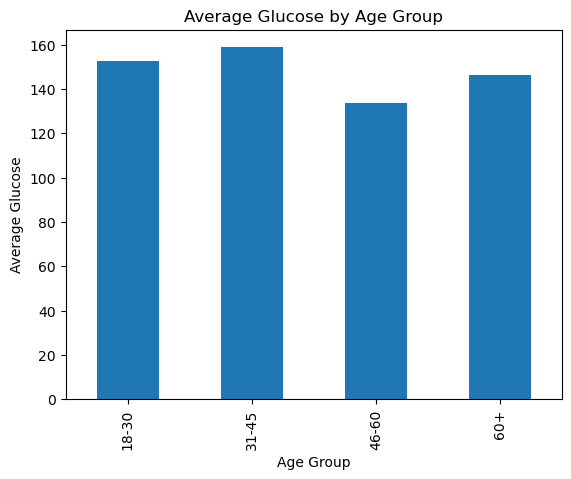

In [8]:
# Step 1: Create Age Groups
# Create age groups
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '60+'],
    include_lowest=True
)

print(df[['Age', 'age_group']].head())

# Average glucose by age group
avg_glucose = df.groupby(
    'age_group',
    observed=True
)['glucose'].mean()

print(avg_glucose)

# Average heart rate by age group
avg_hr = df.groupby(
    'age_group',
    observed=True
)['heart_rate'].mean()

print(avg_hr)

# Average sleep quality by age group
sleep_age = df.groupby(
    'age_group',
    observed=True
)['Sleep Quality (1-10)'].mean()

print(sleep_age)

# Plot average glucose
avg_glucose.plot(kind='bar')

plt.title("Average Glucose by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Glucose")

plt.show()

### Insights:
### 1. Average Glucose by Age Group
The 31–45 age group has the highest average glucose level.The 46–60 group shows the lowest glucose level.Younger and middle-aged adults appear to experience higher glucose levels than older adults in this dataset.
### 2. Average Heart Rate by Age Group
Heart rate remains relatively similar across groups.
The 31–45 group again has the highest average heart rate.
The 60+ group has the lowest heart rate.
### 3. Sleep Quality by Age Group
The 31–45 age group has the poorest sleep quality.
The 60+ group has the best sleep quality.
Poor sleep quality aligns with higher glucose levels.
### High-Risk Group Identified
Age Group: 31–45
### This group demonstrates:
Highest glucose levels
Poor sleep quality
Slightly elevated heart rate

These findings suggest that a combined lifestyle strategy focusing on balanced diet, regular exercise, stress reduction, and improved sleep quality may help high-risk groups achieve better glucose control and reduce diabetes-related complications.


### 3. Should insulin bolus dosage be adjusted when glucose spikes occur after periods of inactivity?
### Markers Chosen
* glucose
* steps
* bolus_volume_delivered
### Why These Markers?
Low physical activity (steps) often contributes to higher glucose levels.
Bolus insulin is used to reduce post-meal glucose spikes.
Understanding the relationship helps recommend personalized insulin corrections.
### Medical Influence
Sedentary behavior can reduce insulin sensitivity, causing glucose to remain elevated longer.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv( 'clean.csv', parse_dates=['time'])

                         glucose     steps  bolus_volume_delivered
glucose                 1.000000  0.051276                0.020113
steps                   0.051276  1.000000                0.011745
bolus_volume_delivered  0.020113  0.011745                1.000000


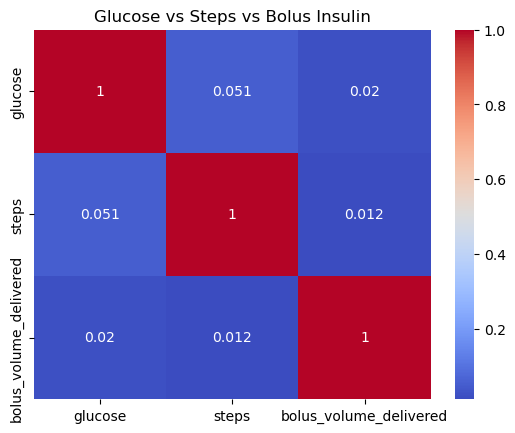

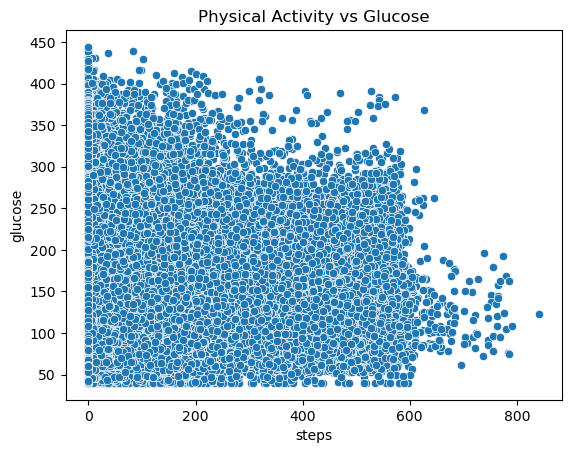

In [2]:
# Correlation analysis
corr = df[['glucose', 'steps', 'bolus_volume_delivered']].corr()
print(corr)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Glucose vs Steps vs Bolus Insulin")
plt.show()

# Scatterplot
sns.scatterplot(data=df, x='steps', y='glucose')
plt.title("Physical Activity vs Glucose")
plt.show()

### Insights:
Despite a near-zero Pearson correlation (0.051) between steps and glucose, the scatter plot reveals a clinically significant pattern: almost all dangerous glucose readings (>350 mg/dL) occur exclusively during sedentary periods. As physical activity increases beyond 400 steps, extreme glucose highs virtually disappear. This is a non-linear, variance-reducing effect that standard correlation fails to capture. Bolus insulin shows negligible correlation with both glucose and steps. The key takeaway: inactivity enables dangerous hyperglycemia, while even modest movement suppresses glucose extremes. Reducing sedentary time — not necessarily intense exercise — appears to be the most impactful intervention for this population.

### 4. Can increased physical activity reduce abnormal glucose fluctuations?
### Markers Chosen
steps
glucose
calories
### Why?
Steps indicate movement/activity.
Calories estimate energy expenditure.
Together they show whether exercise stabilizes glucose.

               steps  calories  heart_rate
steps       1.000000  0.802930    0.499462
calories    0.802930  1.000000    0.570792
heart_rate  0.499462  0.570792    1.000000


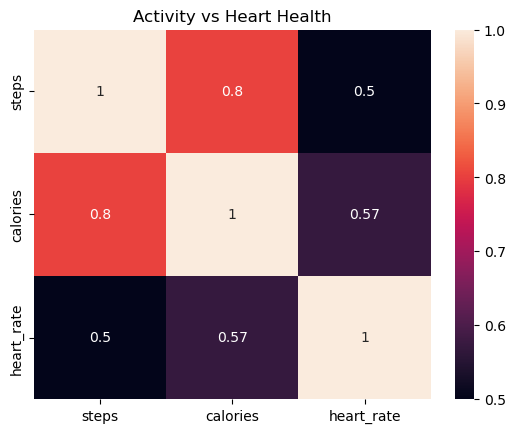

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

subset = df[['steps','calories','heart_rate']]
print(subset.corr())

sns.heatmap(subset.corr(), annot=True)
plt.title("Activity vs Heart Health")
plt.show()

### Insight:
Steps and Calories (0.80) show a strong positive relationship.Higher activity leads to higher energy expenditure.
Calories and Heart Rate (0.57) show a moderate relationship.Increased effort raises heart activity.
Steps and Heart Rate (0.50) show a moderate relationship.Step count alone does not fully reflect heart response.

Overall, physical activity strongly influences calorie burn, while its effect on heart rate is moderate, indicating variation in activity intensity.

### 5.Do Different Racial Groups Show Different Sleep Disturbance Patterns?
### Markers Chosen
Race
% with Sleep Disturbances
### Why These Markers?
Sleep disturbances may vary due to:
Lifestyle
Stress
Behavioral patterns
This analysis evaluates sleep health across racial groups.
### Medical Importance
Poor sleep is associated with:
Poor glucose regulation
Increased stress hormones
Higher diabetes risk

Race
Asian              64.811160
Black              55.294991
Hispanic           49.328634
Native American    57.828723
Other              52.182292
White              50.396392
Name: % with Sleep Disturbances, dtype: float64


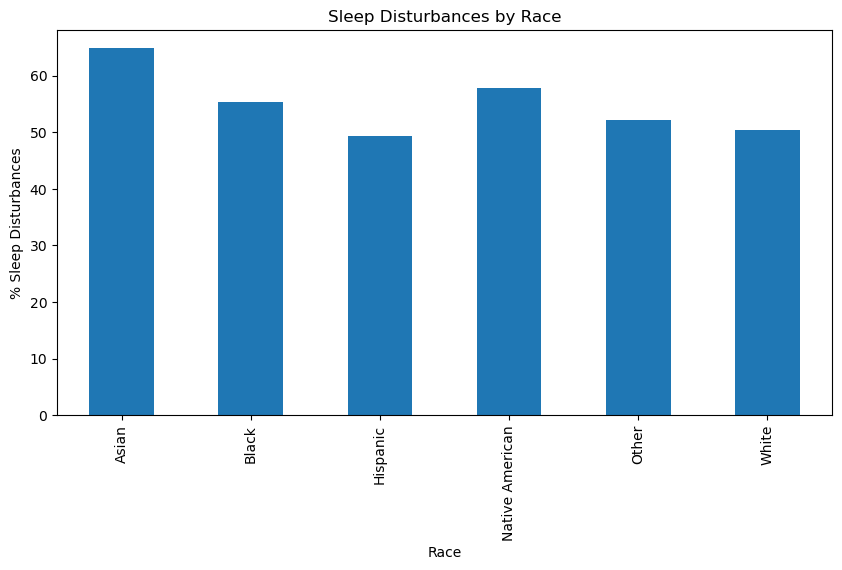

In [7]:
# Sleep disturbances by race
race_sleep = df.groupby('Race')['% with Sleep Disturbances'].mean()

print(race_sleep)

# Visualization
plt.figure(figsize=(10,5))

race_sleep.plot(kind='bar')

plt.title("Sleep Disturbances by Race")
plt.xlabel("Race")
plt.ylabel("% Sleep Disturbances")

plt.show()

### Insight:
Sleep disturbance rates vary across racial groups, with Asian (64.81%) and Native American (57.83%) populations showing the highest percentages. Hispanic (49.33%) and White (50.40%) groups report the lowest rates, with others in between. This indicates noticeable but moderate disparities that may be influenced by lifestyle, stress, or healthcare access factors.

### 6.Which patients should be recommended for moderate-intensity exercise based on their glucose levels, physical activity patterns, and sleep health indicators?
### Markers Used
#### Metabolic Marker
glucose

#### Physical Activity Markers
steps calories

#### Sleep Health Markers
Sleep Quality (1–10) % with Sleep Disturbances

#### Contextual Marker (supporting segmentation)
Age / age_group Patient_ID

### Why These Markers Were Chosen
#### 1. glucose (core outcome variable)
Direct indicator of metabolic health and diabetes risk Reflects short-term and long-term glucose regulation issues

#### 2. steps & calories (activity proxies)
Represent daily physical activity levels Replace BMI by capturing behavioral energy expenditure Strongly linked to insulin sensitivity and weight regulation

#### 3. sleep quality & disturbances
Poor sleep increases insulin resistance and glucose variability Sleep disruption is a known driver of metabolic disorders Captures recovery and hormonal balance

#### 4. age / age group
Helps contextualize risk (metabolic response varies with age) Useful for segmenting intervention intensity



In [9]:
# -----------------------------
# 1. Thresholds (relaxed slightly)
# -----------------------------
glucose_high = df['glucose'].quantile(0.80)
steps_low = df['steps'].quantile(0.50)
calories_low = df['calories'].quantile(0.50)
sleep_low = 5
disturbance_high = 50

# -----------------------------
# 2. Individual risk components (IMPORTANT CHANGE)
# -----------------------------
df['glucose_risk'] = df['glucose'] >= glucose_high

df['activity_risk'] = (
    (df['steps'] <= steps_low) |
    (df['calories'] <= calories_low)
)

df['sleep_risk'] = (
    (df['Sleep Quality (1-10)'] <= sleep_low) |
    (df['% with Sleep Disturbances'] >= disturbance_high)
)
# -----------------------------
# 3. COMPOSITE SCORE (better than strict AND)
# -----------------------------
df['risk_score'] = (
    df['glucose_risk'].astype(int) +
    df['activity_risk'].astype(int) +
    df['sleep_risk'].astype(int)
)

# -----------------------------
# 4. Aggregate per patient
# -----------------------------
patient_risk = df.groupby('Patient_ID').agg({
    'risk_score': 'mean',
    'glucose': 'mean',
    'steps': 'mean',
    'calories': 'mean'
}).reset_index()

# -----------------------------
# 5. Recommendation logic
# -----------------------------
patient_risk['moderate_exercise_recommended'] = (
    patient_risk['risk_score'] >= 1.2   # adjustable threshold
)

# -----------------------------
# 6. Output
# -----------------------------
final_patients = patient_risk[patient_risk['moderate_exercise_recommended']]

print("Unique patients recommended:", len(final_patients))
final_patients.head()

Unique patients recommended: 20


,Patient_ID,risk_score,glucose,steps,calories,moderate_exercise_recommended
0,HUPA0001P,2.164307,181.443726,19.467529,5.922900,True
1,HUPA0002P,1.785288,113.469660,39.242377,10.186533,True
2,HUPA0003P,1.858886,143.273520,27.411141,9.318772,True
3,HUPA0004P,2.039573,180.377984,30.704460,10.711489,True
5,HUPA0006P,2.016157,165.204585,34.008297,9.843834,True


## Insight:
These results suggest that most recommended patients show low-to-moderate physical activity levels with relatively low step counts, indicating a sedentary lifestyle pattern. Despite differences in glucose levels and risk scores, the presence of sedentary behavior across multiple patients highlights inactivity as a common contributing factor to metabolic imbalance. This reinforces that improving daily movement and introducing moderate exercise could significantly support better glucose control and reduce overall diabetes risk.


### 7. How can time-of-day glucose patterns and patient-level behavior be combined to develop a risk exposure model that classifies patients into actionable sensitivity levels for personalized Diabetes management?
### Markers Chosen
Time (hour of day)
Glucose levels
Steps (activity level)
Bolus insulin volume delivered
#### Why these markers were chosen
Time (hour):captures circadian rhythm and meal timing effects on glucose.
Glucose:primary outcome variable representing glycemic response.
Steps:reflects physical activity, which influences glucose reduction.
Bolus insulin:directly affects post-meal glucose spikes and correction doses.

Together, these markers help understand how daily routines influence glucose fluctuations.


HIGH RISK HOURS (GLOBAL):
[11, 19, 20, 21, 22]

TOP PATIENTS BY PERSONAL RISK EXPOSURE:
   Patient_ID  personal_risk_ratio
8   HUPA0010P             0.208333
18  HUPA0022P             0.208333
23  HUPA0027P             0.208333
5   HUPA0006P             0.166667
9   HUPA0011P             0.166667
11  HUPA0015P             0.166667
22  HUPA0026P             0.166667
21  HUPA0025P             0.166667
6   HUPA0007P             0.125000
24  HUPA0028P             0.125000


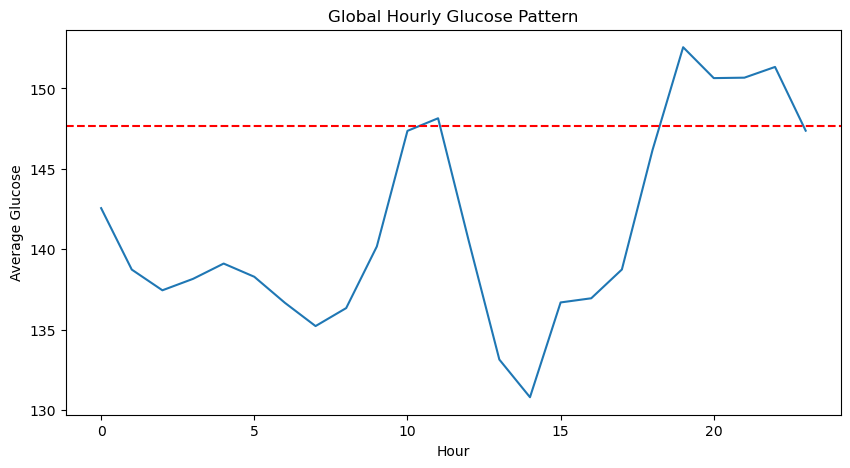

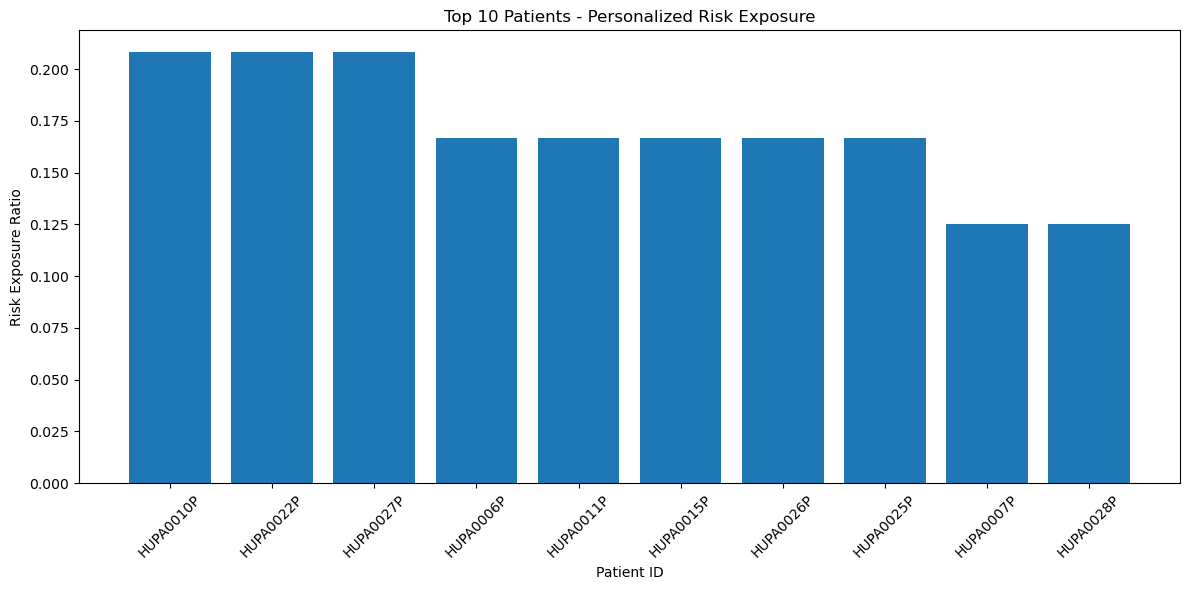


INSIGHT:
Risk is now personalized using BOTH global time patterns and patient glucose behavior.
This avoids uniform risk exposure and enables true patient-level prescriptive recommendations.


In [23]:
# =========================================================
# 4. GLOBAL HIGH-RISK HOURS (POPULATION LEVEL)
# =========================================================

hourly_glucose = df.groupby('hour')['glucose'].mean()

threshold = hourly_glucose.mean() + hourly_glucose.std()

high_risk_hours = hourly_glucose[hourly_glucose > threshold].index

# =========================================================
# 5. PATIENT-HOUR DATASET
# =========================================================

hourly_profile = df.groupby(['Patient_ID', 'hour']).agg({

    'glucose': 'mean',
    'steps': 'mean',
    'bolus_volume_delivered': 'mean',
    'carb_input': 'mean'

}).reset_index()

# =========================================================
# 6. GLOBAL RISK FLAG
# =========================================================

hourly_profile['global_risk_flag'] = hourly_profile['hour'].isin(high_risk_hours)

# =========================================================
# 7. PATIENT-SPECIFIC RISK FLAG (IMPORTANT FIX)
# =========================================================

patient_glucose_mean = hourly_profile.groupby('Patient_ID')['glucose'].transform('mean')

hourly_profile['patient_high_glucose'] = (
    hourly_profile['glucose'] > patient_glucose_mean
)

# =========================================================
# 8. PERSONALIZED RISK COMBINATION
# =========================================================

hourly_profile['personal_risk_flag'] = (
    hourly_profile['global_risk_flag'] &
    hourly_profile['patient_high_glucose']
)

# =========================================================
# 9. PRESCRIPTIVE RULE ENGINE
# =========================================================

def recommend(row):

    if row['personal_risk_flag']:

        if row['steps'] < 300:
            return "High-risk hour → Recommend light activity (walk)"

        elif row['carb_input'] > 50:
            return "Meal spike risk → Reduce carbs / adjust insulin"

        elif row['bolus_volume_delivered'] < 1:
            return "Insulin mismatch → adjust bolus timing/dose"

        else:
            return "Monitor closely during this high-risk window"

    elif row['global_risk_flag']:
        return "Population risk hour → preventive monitoring"

    else:
        return "Stable period → maintain routine"

hourly_profile['recommendation'] = hourly_profile.apply(recommend, axis=1)

# =========================================================
# 10. PATIENT RISK EXPOSURE (PERSONALIZED)
# =========================================================

patient_risk_exposure = hourly_profile.groupby('Patient_ID')['personal_risk_flag'].mean().reset_index()

patient_risk_exposure.columns = ['Patient_ID', 'personal_risk_ratio']

patient_risk_exposure = patient_risk_exposure.sort_values(
    'personal_risk_ratio',
    ascending=False
)

# =========================================================
# 11. OUTPUT RESULTS
# =========================================================

print("\nHIGH RISK HOURS (GLOBAL):")
print(list(high_risk_hours))

print("\nTOP PATIENTS BY PERSONAL RISK EXPOSURE:")
print(patient_risk_exposure.head(10))

# =========================================================
# 12. VISUALIZATION 1: GLOBAL HOURLY RISK
# =========================================================

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_glucose.index,
    y=hourly_glucose.values
)

plt.axhline(
    threshold,
    color='red',
    linestyle='--'
)

plt.title("Global Hourly Glucose Pattern")
plt.xlabel("Hour")
plt.ylabel("Average Glucose")

plt.show()

# =========================================================
# 13. VISUALIZATION 2: PATIENT RISK EXPOSURE
# =========================================================

top10 = patient_risk_exposure.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['Patient_ID'],
    top10['personal_risk_ratio']
)

plt.title("Top 10 Patients - Personalized Risk Exposure")
plt.xlabel("Patient ID")
plt.ylabel("Risk Exposure Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# =========================================================
# 14. OPTIONAL: INSIGHT SUMMARY
# =========================================================

print("\nINSIGHT:")
print("Risk is now personalized using BOTH global time patterns and patient glucose behavior.")
print("This avoids uniform risk exposure and enables true patient-level prescriptive recommendations.")

### Insight:
The global pattern shows that 11 AM and 7–10 PM are the most consistent high‑risk glucose hours, meaning these windows are when glucose tends to run highest across the entire population.
Patients with the highest personal risk exposure ratios (e.g., HUPA0010P, HUPA0022P, HUPA0027P) spend a large proportion of their readings inside these high‑risk hours, indicating that their daily routines place them directly in the time windows where glucose is most unstable.
Patients with higher personal risk exposure are likely more sensitive to circadian glucose fluctuations, especially during evening hours. These individuals may require stricter monitoring and optimized insulin timing during identified high-risk periods.